# B2d - learned bettor: trajectory analysis (scratch)

Investigation aid, **not** the report. Loads `kind=='bet_agent'` runs and visualizes the *training
trajectory* the text logs can't show well:

- **the orbit** - bet level vs count over training (constant-lr *wanders*; harmonic *collapses* it),
- **distance to Kelly** - the orbit *passing through* near-Kelly ramps it doesn't keep (Test 11 / H-series),
- **neutral-region stability** - the achievable target (`-4..+2` should lock to ~1).

Structure (deliberately, as the pattern for new notebooks): a **pure data layer** (`load_bet_runs`,
`trajectory`, `kelly_distance`, `select_demo`, `run_label` - records -> typed arrays, no side effects)
separated from a **plotting shell** (`plot_*` - the matplotlib effects). Everything reads each run's
`record.json` (`metrics.learning_curve`) - no heavy compute, no eval here (that's in
`logs/real_sweep/eval_*.out`). Works on any bet run; re-run after the sweep lands.

In [36]:
import glob
import json
import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents] if (p / "runs").is_dir()), Path.cwd())
RUNS = ROOT / "runs"
COUNTS: list[int] = [-4, -2, 0, 2, 4, 6, 8]
KELLY: dict[int, int] = {-4: 1, -2: 1, 0: 1, 2: 2, 4: 5, 6: 8, 8: 8}  # discrete-Kelly ladder (the target)

## Pure data layer

Records -> typed arrays. No plotting, no global state - each function has one job and a name that
reveals it, so the views below are just thin shells over these.

In [37]:
def _bet_at(checkpoint: dict, count: int) -> float:
    """Bet level at one count from one checkpoint (JSON stringifies the int keys)."""
    bets = checkpoint["bet_by_count"]
    return float(bets.get(str(count), bets.get(count)))


def load_bet_runs() -> pd.DataFrame:
    """Every kind=='bet_agent' run as one tidy frame: config + trajectory length."""
    rows = []
    for record_path in sorted(glob.glob(str(RUNS / "*" / "record.json")), key=os.path.getmtime):
        try:
            record = json.load(open(record_path, encoding="utf-8"))
        except Exception:
            continue
        if record.get("kind") != "bet_agent":
            continue
        config = record.get("config", {}) or {}
        metrics = record.get("metrics", {}) or {}
        session = config.get("session", {}) or {}
        run_dir = Path(record_path).parent
        rows.append({
            "run": run_dir.name,
            "regime": "growth" if (session.get("starting_bankroll") or 0) >= 400 else "ruin",
            "gamma": config.get("gamma"),
            "double": bool(config.get("double_dqn")),
            "scale": config.get("reward_scale"),
            "batch": config.get("batch_size"),
            "lr_sched": config.get("lr_schedule"),
            "n_sess": config.get("n_sessions"),
            "n_ckpt": len(metrics.get("learning_curve", [])),
            "saved_ckpts": (run_dir / "checkpoints").is_dir(),
            "path": str(run_dir),
        })
    return pd.DataFrame(rows)


def trajectory(run_path: str) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    """One run's training trajectory: (sessions, loss, bets), bets shaped (checkpoint, count) - the orbit."""
    curve = json.load(open(Path(run_path) / "record.json", encoding="utf-8"))["metrics"]["learning_curve"]
    sessions = np.array([cp["session"] for cp in curve])
    loss = np.array([cp["recent_loss"] if cp.get("recent_loss") is not None else np.nan for cp in curve], float)
    bets = np.array([[_bet_at(cp, c) for c in COUNTS] for cp in curve], dtype=float)
    return sessions, loss, bets


def kelly_distance(bets: np.ndarray) -> np.ndarray:
    """L1 distance of each checkpoint's bet curve to the Kelly ladder (low = near-Kelly)."""
    return np.abs(bets - np.array([KELLY[c] for c in COUNTS])).sum(axis=1)


def select_demo(runs: pd.DataFrame) -> str:
    """A representative run to illustrate the views: prefer the latest harmonic run, else the latest."""
    harmonic = runs[runs.lr_sched == "harmonic"]
    return str((harmonic.iloc[-1] if len(harmonic) else runs.iloc[-1])["path"])


def run_label(row: pd.Series) -> str:
    """Compact config label for a legend: regime / double / batch."""
    return f"{row.regime[:1]}/{'on' if row.double else 'off'}/b{row.batch}"

In [38]:
df = load_bet_runs()
print(f"{len(df)} bet runs found  (harmonic: {int((df.lr_sched == 'harmonic').sum())})")
df.tail(16)

59 bet runs found  (harmonic: 38)


,run,regime,gamma,double,scale,batch,lr_sched,n_sess,n_ckpt,saved_ckpts,path
43,20260701-035656_bet-agent_ruin_b512_2000sess,ruin,0.95,False,50.0,512,harmonic,2000,20,True,c:\Users\ardab\Desktop\ai_journey\phase3-deep-...
44,20260701-035656_bet-agent_ruin_b512_2000sess-1,ruin,0.95,False,50.0,512,harmonic,2000,20,True,c:\Users\ardab\Desktop\ai_journey\phase3-deep-...
45,20260701-035656_bet-agent_growth_b512_2000sess,growth,0.00,False,50.0,512,harmonic,2000,20,True,c:\Users\ardab\Desktop\ai_journey\phase3-deep-...
46,20260701-035656_bet-agent_growth_b512_2000sess-1,growth,0.00,False,50.0,512,harmonic,2000,20,True,c:\Users\ardab\Desktop\ai_journey\phase3-deep-...
47,20260701-035656_bet-agent_growth_b512_2000sess-2,growth,0.00,False,50.0,512,harmonic,2000,20,True,c:\Users\ardab\Desktop\ai_journey\phase3-deep-...
48,20260701-035656_bet-agent_ruin_b512_2000sess-2,ruin,0.95,True,50.0,512,harmonic,2000,20,True,c:\Users\ardab\Desktop\ai_journey\phase3-deep-...
49,20260701-035656_bet-agent_ruin_b512_2000sess-3,ruin,0.95,True,50.0,512,harmonic,2000,20,True,c:\Users\ardab\Desktop\ai_journey\phase3-deep-...
50,20260701-035656_bet-agent_ruin_b512_2000sess-4,ruin,0.95,True,50.0,512,harmonic,2000,20,True,c:\Users\ardab\Desktop\ai_journey\phase3-deep-...
51,20260701-043502_bet-agent_ruin_b512_2000sess,ruin,0.90,False,50.0,512,harmonic,2000,20,True,c:\Users\ardab\Desktop\ai_journey\phase3-deep-...
52,20260701-043502_bet-agent_ruin_b512_2000sess-1,ruin,0.99,False,50.0,512,harmonic,2000,20,True,c:\Users\ardab\Desktop\ai_journey\phase3-deep-...


## Plotting shell

Each `plot_*` is one figure, one responsibility - a thin effectful wrapper over the pure layer above.

### The orbit - bet level vs count over training

x = session, y = count, colour = bet level. Constant-lr **wanders** (colour shifts); harmonic
**collapses** to a stable pattern (loss panel shows its drop).

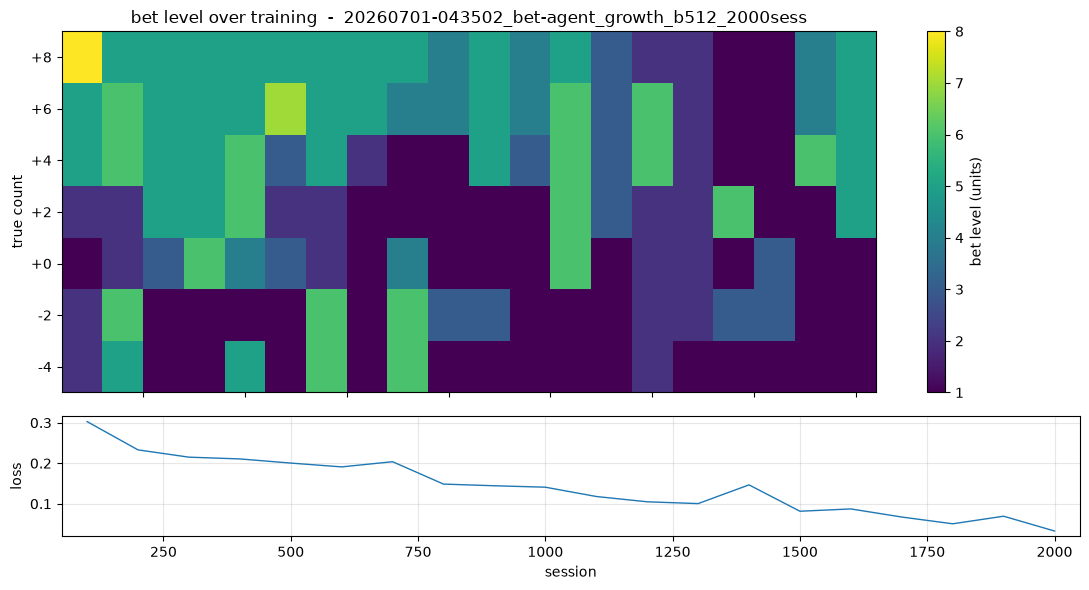

In [39]:
def plot_orbit(run_path: str) -> None:
    """Heatmap of bet level vs count over training, with the loss curve below."""
    sessions, loss, bets = trajectory(run_path)
    fig, (heat, loss_ax) = plt.subplots(2, 1, figsize=(11, 6), sharex=True,
                                        gridspec_kw={"height_ratios": [3, 1]})
    mesh = heat.pcolormesh(sessions, np.arange(len(COUNTS)), bets.T, cmap="viridis",
                           shading="nearest", vmin=1, vmax=8)
    heat.set_yticks(np.arange(len(COUNTS)))
    heat.set_yticklabels([f"{c:+d}" for c in COUNTS])
    heat.set(ylabel="true count", title=f"bet level over training  -  {Path(run_path).name}")
    fig.colorbar(mesh, ax=heat, label="bet level (units)")
    loss_ax.plot(sessions, loss, lw=1)
    loss_ax.set(ylabel="loss", xlabel="session")
    loss_ax.grid(alpha=0.3)
    fig.tight_layout()
    plt.show()


demo = select_demo(df)
plot_orbit(demo)

### Distance to Kelly over training

L1 distance of the bet curve to the Kelly ladder per checkpoint. **Dips = the orbit passing through
near-Kelly ramps** it doesn't keep. dist <= 2 (dashed) ~ essentially Kelly.

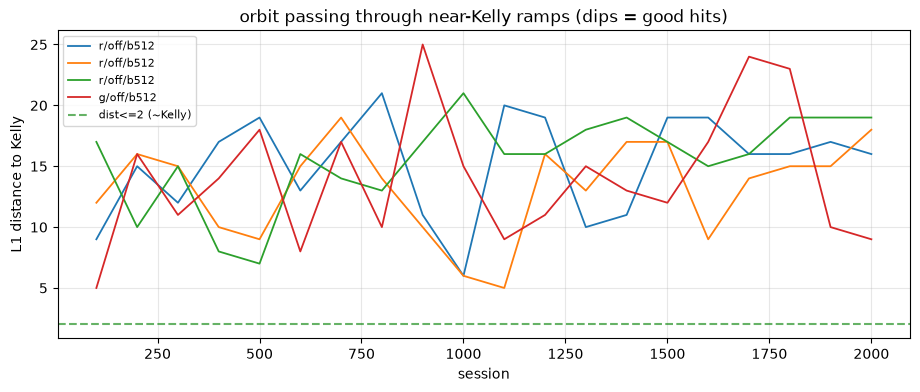

In [40]:
def plot_kelly_distance(runs: pd.DataFrame) -> None:
    """L1-distance-to-Kelly over training for several runs; dips mark near-Kelly ramps the orbit visits."""
    plt.figure(figsize=(11, 4))
    for _, row in runs.iterrows():
        sessions, _, bets = trajectory(row.path)
        plt.plot(sessions, kelly_distance(bets), lw=1.3, label=run_label(row))
    plt.axhline(2, ls="--", c="green", alpha=0.6, label="dist<=2 (~Kelly)")
    plt.gca().set(ylabel="L1 distance to Kelly", xlabel="session",
                  title="orbit passing through near-Kelly ramps (dips = good hits)")
    plt.legend(fontsize=8)
    plt.grid(alpha=0.3)
    plt.show()


harmonic_runs = df[df.lr_sched == "harmonic"]
plot_kelly_distance(harmonic_runs.tail(4) if len(harmonic_runs) else df.tail(4))

### Neutral-region stability (the achievable target)

`-4, -2, 0, +2` should lock to ~1 (Kelly bets minimum at neutral). A flat line at 1 = solid;
jumps = the residual orbit (constant lr) or double-DQN noise.

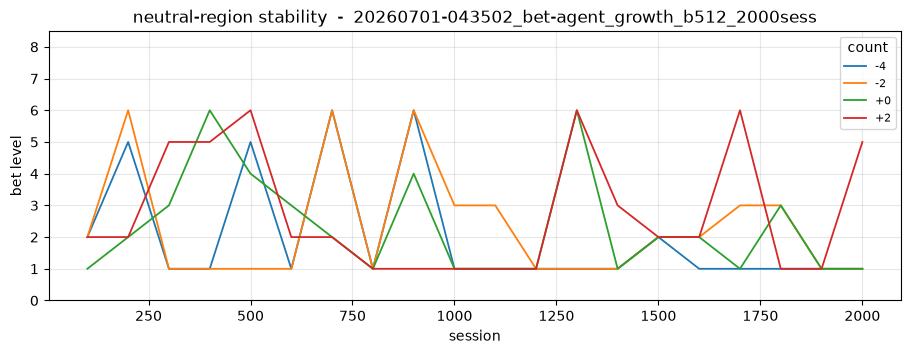

In [41]:
def plot_neutral(run_path: str) -> None:
    """Bet level at the neutral counts (-4..+2) over training - the achievable target."""
    sessions, _, bets = trajectory(run_path)
    plt.figure(figsize=(11, 3.5))
    for count in [-4, -2, 0, 2]:
        plt.plot(sessions, bets[:, COUNTS.index(count)], lw=1.3, label=f"{count:+d}")
    plt.gca().set(ylabel="bet level", xlabel="session", ylim=(0, 8.5),
                  title=f"neutral-region stability  -  {Path(run_path).name}")
    plt.legend(title="count", fontsize=8)
    plt.grid(alpha=0.3)
    plt.show()


plot_neutral(demo)

## Learned representation - PCA / t-SNE embeddings (coloured by action)

The penultimate-layer activations (`q_net.features`, post final ReLU) are the net's internal state
representation. Projected to 2-D and coloured three ways:

- by **bet level** (the action) - does the representation separate the chosen bets?
- by **true count** (the feature that *should* drive betting),
- by **bankroll** (the feature it may have *spuriously* keyed on - the four-axis over-betting).

**Read:** clusters organised by **count** = it learned the edge structure; organised by **bankroll** =
the wealth-scaling failure; one blob / single bet colour = a flat policy. (Needs `model.pt`; loads the
agent via `load_bet_agent`. Swap `demo` for any run path.)

In [42]:
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

from blackjack_rl.session.persistence import load_bet_agent


def sample_states(counts=range(-8, 11),
                  depths=(1.0, 2.0, 3.0, 4.5, 6.0),
                  bankrolls=(50, 100, 150, 200, 300, 400, 500, 600)) -> pd.DataFrame:
    """A grid of (true_count, decks_remaining, bankroll) states to probe the learned representation."""
    return pd.DataFrame([
        {"true_count": tc, "decks_remaining": d, "bankroll": b}
        for tc in counts for d in depths for b in bankrolls
    ])


def embed_states(agent, states: pd.DataFrame) -> dict:
    """Penultimate-layer embedding + greedy bet level for each state (arrays aligned with `states`)."""
    import torch
    features = torch.tensor(
        [agent.encode_state(r.true_count, r.decks_remaining, r.bankroll) for r in states.itertuples()],
        dtype=torch.float32,
    )
    with torch.no_grad():
        embedding = agent.q_net.features(features).numpy()
        bet = np.array(agent.levels)[agent.q_net(features).argmax(1).numpy()]
    return {"embedding": embedding, "bet": bet}


def project(embedding: np.ndarray, method: str, seed: int = 0) -> np.ndarray:
    """2-D projection: 'pca' (linear, fast) or 'tsne' (local structure)."""
    if method == "pca":
        return PCA(n_components=2, random_state=seed).fit_transform(embedding)
    return TSNE(n_components=2, init="pca", random_state=seed,
                perplexity=min(30, len(embedding) - 1)).fit_transform(embedding)

In [43]:
def plot_embedding(coords: np.ndarray, color, label: str, title: str, cmap: str = "viridis") -> None:
    """One 2-D embedding scatter, coloured by `color`."""
    plt.figure(figsize=(6, 5))
    points = plt.scatter(coords[:, 0], coords[:, 1], c=color, cmap=cmap, s=10, alpha=0.7)
    plt.colorbar(points, label=label)
    plt.gca().set(xticks=[], yticks=[], title=title)
    plt.tight_layout()
    plt.show()


def plot_projection(coords: np.ndarray, states: pd.DataFrame, bet: np.ndarray, method: str) -> None:
    """The three diagnostic colourings of one projection: action, count, bankroll."""
    plot_embedding(coords, bet, "bet level", f"{method} - coloured by bet level", cmap="plasma")
    plot_embedding(coords, states.true_count, "true count", f"{method} - coloured by count", cmap="coolwarm")
    plot_embedding(coords, states.bankroll, "bankroll", f"{method} - coloured by bankroll", cmap="viridis")

In [44]:
agent = load_bet_agent(demo)
states = sample_states()
emb = embed_states(agent, states)
print(f"{len(states)} states | embedding dim {emb['embedding'].shape[1]} | "
      f"distinct greedy bets: {sorted(set(emb['bet'].tolist()))}")

760 states | embedding dim 64 | distinct greedy bets: [1.0, 3.0, 4.0, 5.0, 8.0]


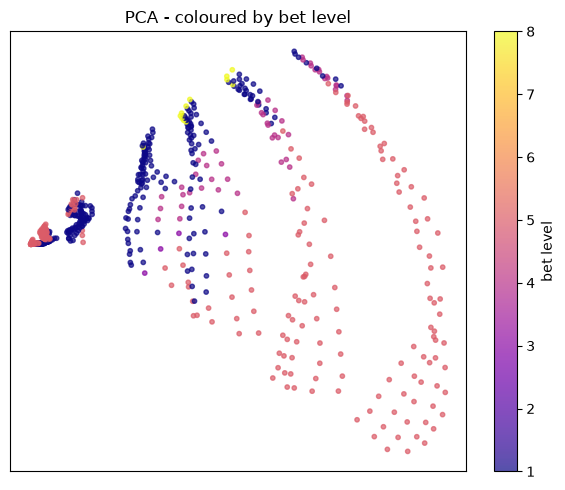

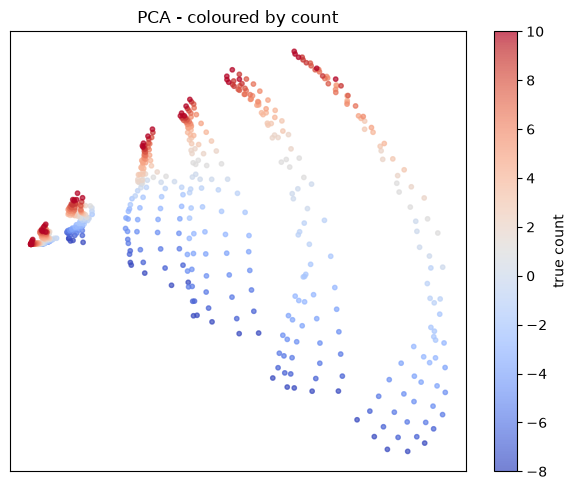

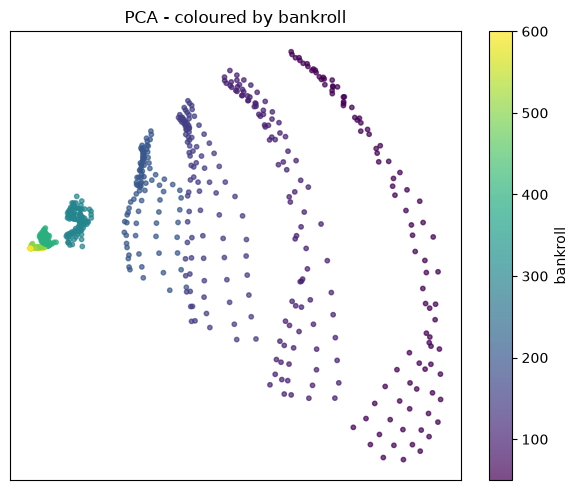

In [45]:
plot_projection(project(emb["embedding"], "pca"), states, emb["bet"], "PCA")

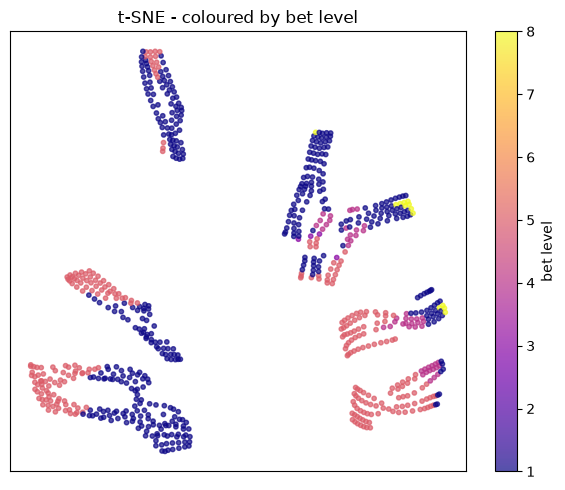

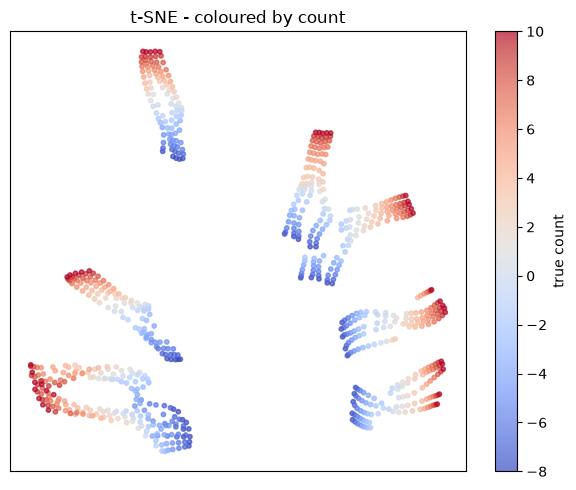

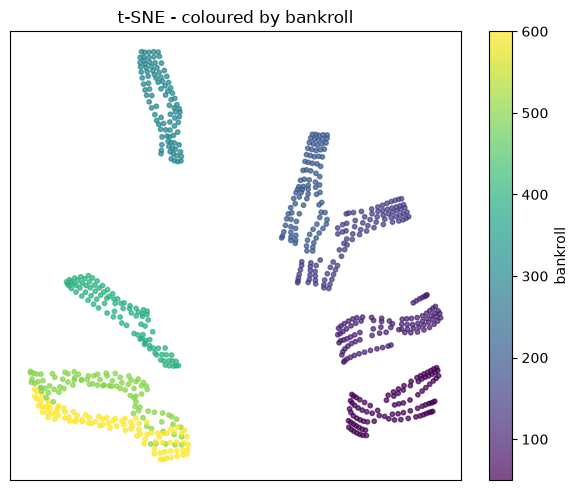

In [46]:
plot_projection(project(emb["embedding"], "tsne"), states, emb["bet"], "t-SNE")

## Four-axis eval — final vs best checkpoint

Loads the saved eval results (`runs/<id>/eval_*.json`, written by `eval_bet_agent`). Compares each run's
**final** policy against its **best-ramp checkpoint** (the H3 diagnostic) on the risk axes, with Kelly/Flat
as dashed references. Read: if the best-ckpt bar isn't *lower-risk / higher-growth* than final **and** near
the baselines, the visited ramp wasn't a genuinely better policy. (Populates as evals are saved.)

In [47]:
def _dd_pct(cell_metrics: dict) -> float:
    """Deep-drawdown breach % from one cell's metrics (the drawdown key carries its level, e.g. _0.5)."""
    key = next(k for k in cell_metrics if k.startswith("drawdown_breach"))
    return cell_metrics[key]["estimate"] * 100


def _bankroll_p50(cell_metrics: dict) -> float:
    quantiles = cell_metrics["bankroll"]["quantiles"]
    return quantiles.get("0.5", quantiles.get(0.5))  # JSON stringified the float keys


def load_bet_evals() -> pd.DataFrame:
    """Saved four-axis evals (runs/<id>/eval_*.json) -> one row per (run, phase, regime, bettor)."""
    rows = []
    for f in sorted(glob.glob(str(RUNS / "*" / "eval_*.json"))):
        try:
            rec = json.load(open(f, encoding="utf-8"))
        except Exception:
            continue
        if rec.get("kind") != "bet_eval":
            continue
        cfg = json.load(open(Path(f).parent / "record.json", encoding="utf-8"))["config"]
        train_regime = "growth" if (cfg.get("session", {}).get("starting_bankroll", 0) >= 400) else "ruin"
        phase = "final" if rec.get("checkpoint_session") is None else "best-ckpt"
        for label, m in rec["metrics"].items():
            regime, bettor = label.split("/")
            rows.append({
                "run": Path(f).parent.name, "phase": phase, "regime": regime, "bettor": bettor,
                "train_regime": train_regime, "seed": cfg.get("seed"), "gamma": cfg.get("gamma"),
                "double": "on" if cfg.get("double_dqn") else "off",
                "growth_1e4": m["growth_rate"]["value"] * 1e4, "ruin_pct": m["ruin"]["estimate"] * 100,
                "dd_pct": _dd_pct(m), "bankroll_p50": _bankroll_p50(m), "n_sessions": rec["n_sessions"],
            })
    return pd.DataFrame(rows)


evals = load_bet_evals()
print(f"{len(evals)} eval rows from {evals.run.nunique() if len(evals) else 0} runs" if len(evals)
      else "no saved evals yet — run eval_bet_agent / eval_best_checkpoints first")
evals[evals.bettor == "agent"].sort_values(["run", "phase"]) if len(evals) else evals

336 eval rows from 32 runs


,run,phase,regime,bettor,train_regime,seed,gamma,double,growth_1e4,ruin_pct,dd_pct,bankroll_p50,n_sessions
4,20260701-002030_bet-agent_growth_b2048_2000sess,best-ckpt,growth,agent,growth,0,0.0,off,-0.919825,0.55,9.40,362.75,2000
5,20260701-002030_bet-agent_growth_b2048_2000sess,best-ckpt,ruin,agent,growth,0,0.0,off,-3.507264,17.60,43.65,228.25,2000
16,20260701-002030_bet-agent_growth_b512_5000sess,best-ckpt,growth,agent,growth,0,0.0,off,-0.469423,0.30,5.55,399.25,2000
17,20260701-002030_bet-agent_growth_b512_5000sess,best-ckpt,ruin,agent,growth,0,0.0,off,-11.086475,23.40,52.35,230.00,2000
10,20260701-002030_bet-agent_growth_b512_5000sess-1,best-ckpt,growth,agent,growth,0,0.0,on,-0.192000,0.05,0.65,391.00,2000
...,...,...,...,...,...,...,...,...,...,...,...,...,...
311,20260701-043502_bet-agent_ruin_b512_2000sess-5,final,ruin,agent,ruin,2,0.9,off,-0.471296,0.00,2.25,196.50,2000
316,20260701-043502_bet-agent_ruin_b512_2000sess-6,best-ckpt,growth,agent,ruin,1,0.9,off,-1.081661,0.00,6.60,341.00,2000
317,20260701-043502_bet-agent_ruin_b512_2000sess-6,best-ckpt,ruin,agent,ruin,1,0.9,off,-1.137520,0.30,19.10,194.00,2000
322,20260701-043502_bet-agent_ruin_b512_2000sess-6,final,growth,agent,ruin,1,0.9,off,-0.421033,0.00,0.00,371.00,2000


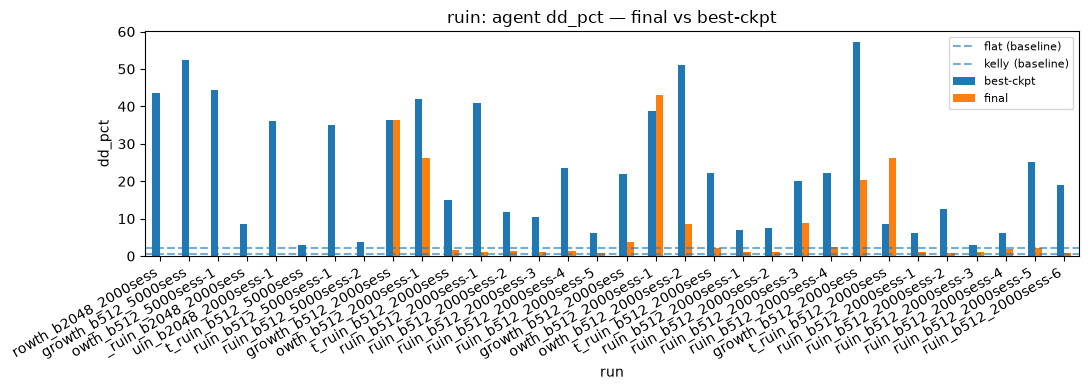

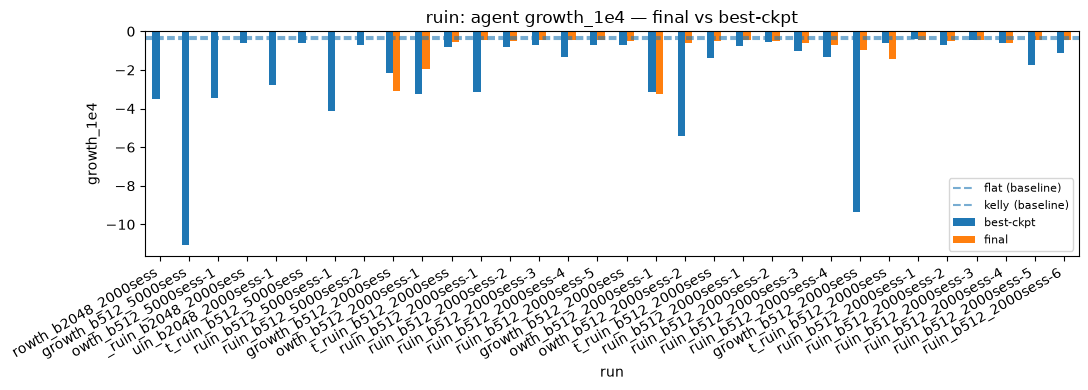

In [48]:
def plot_final_vs_best(evals: pd.DataFrame, regime: str = "ruin", metric: str = "dd_pct") -> None:
    """Per-run agent `metric` at final vs best-ckpt (grouped bars), with kelly/flat as dashed references."""
    agent = evals[(evals.regime == regime) & (evals.bettor == "agent")]
    if agent.empty:
        print(f"no agent evals for regime={regime} yet")
        return
    ax = agent.pivot_table(index="run", columns="phase", values=metric).plot(kind="bar", figsize=(11, 4))
    baseline = evals[(evals.regime == regime) & (evals.bettor != "agent")]
    for bettor, sub in baseline.groupby("bettor"):
        ax.axhline(sub[metric].iloc[0], ls="--", alpha=0.6, label=f"{bettor} (baseline)")
    ax.set(ylabel=metric, title=f"{regime}: agent {metric} — final vs best-ckpt")
    ax.legend(fontsize=8)
    ax.set_xticklabels([t.get_text()[-20:] for t in ax.get_xticklabels()], rotation=30, ha="right")
    plt.tight_layout()
    plt.show()


if len(evals):
    plot_final_vs_best(evals, "ruin", "dd_pct")
    plot_final_vs_best(evals, "ruin", "growth_1e4")

### Multi-seed summary (mean ± std across seeds)

Groups the *native-regime* agent evals by config (regime / γ / double / phase) and aggregates across seeds
— the hardened, CI-backed view. This is where single-seed artifacts get caught (e.g. double-ON's dd
variance). Bars show mean with ±std error bars.

In [49]:
def multiseed_summary(evals: pd.DataFrame) -> pd.DataFrame:
    """Per-config mean/std across seeds, native-regime agent cell (train_regime == eval regime)."""
    native = evals[(evals.bettor == "agent") & (evals.regime == evals.train_regime)]
    grouped = native.groupby(["train_regime", "gamma", "double", "phase"])
    return grouped.agg(
        n=("seed", "nunique"),
        growth=("growth_1e4", "mean"), growth_sd=("growth_1e4", "std"),
        dd=("dd_pct", "mean"), dd_sd=("dd_pct", "std"),
    ).round(2).reset_index()


def plot_multiseed(evals: pd.DataFrame, phase: str = "final", metric: str = "dd_pct") -> None:
    """Per-config mean±std bars for one phase (native regime agents)."""
    native = evals[(evals.bettor == "agent") & (evals.regime == evals.train_regime) & (evals.phase == phase)]
    if native.empty:
        print(f"no {phase} evals yet")
        return
    stat = native.groupby(["train_regime", "gamma", "double"])[metric]
    means, sds = stat.mean(), stat.std()
    labels = [f"{r}/g{g}/{d}" for (r, g, d) in means.index]
    plt.figure(figsize=(11, 4))
    plt.bar(range(len(means)), means.values, yerr=sds.values, capsize=4, alpha=0.8)
    plt.xticks(range(len(means)), labels, rotation=30, ha="right")
    plt.gca().set(ylabel=metric, title=f"multi-seed {phase}: {metric} (mean ± std)")
    plt.grid(alpha=0.3, axis="y")
    plt.tight_layout()
    plt.show()


multiseed_summary(evals) if len(evals) else evals

,train_regime,gamma,double,phase,n,growth,growth_sd,dd,dd_sd
0,growth,0.00,off,best-ckpt,6,-0.56,0.21,5.58,3.76
1,growth,0.00,off,final,6,-0.19,0.08,0.18,0.29
2,growth,0.00,on,best-ckpt,1,-0.19,NaN,0.65,NaN
3,ruin,0.90,off,best-ckpt,3,-1.17,0.58,17.65,8.42
4,ruin,0.90,off,final,3,-0.79,0.56,9.83,14.28
5,ruin,0.95,off,best-ckpt,6,-1.08,0.88,13.92,12.66
6,ruin,0.95,off,final,6,-0.48,0.04,1.39,0.44
7,ruin,0.95,on,best-ckpt,6,-1.48,1.21,18.29,12.17
8,ruin,0.95,on,final,6,-0.52,0.11,2.60,3.05
9,ruin,0.99,off,best-ckpt,3,-0.58,0.15,8.27,3.67


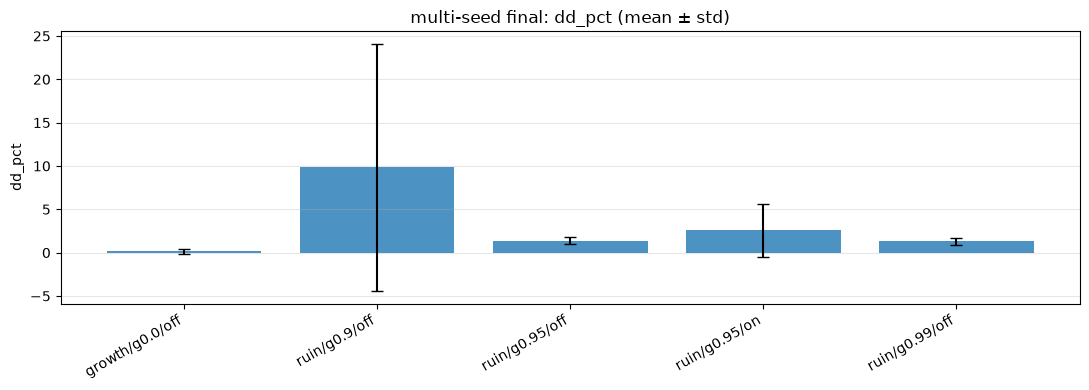

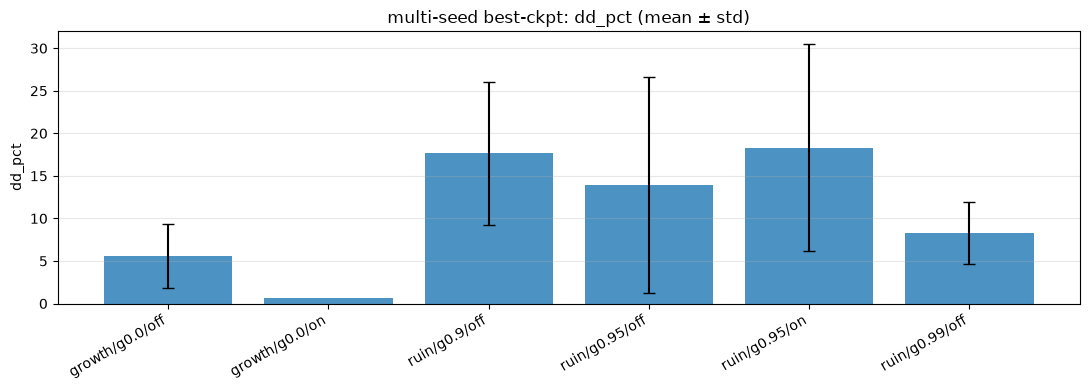

In [50]:
if len(evals):
    plot_multiseed(evals, "final", "dd_pct")
    plot_multiseed(evals, "best-ckpt", "dd_pct")

## Notes / next

- **Four-axis eval** (growth-rate / ruin / drawdown / bankroll) is in `logs/real_sweep/eval_*.out` - add a
  parser + bar-plot here when the story settles (or run `eval_bet_agent.py` for a fresh agent).
- **H3 ramp capture** - for runs with `saved_ckpts=True`, `load_bet_checkpoint(path, session)` rebuilds a
  *mid-training* policy (the near-Kelly ramp) to eval as a diagnostic.
- If these views prove useful, promote `load_bet_runs` / `trajectory` into `analysis_loader.py` (bet-aware
  companions to the Problem-A loaders, kept to the same pure-layer discipline).